# Maritime Tracker: Train Rich Telemetry LSTM
This model uses 12 features: the object's `[dx, dy, w, h]` PLUS the drone's `[gps_lat, gps_lon, altitude, pitch, heading, xspeed, yspeed, zspeed]`. It predicts the next `[dx, dy, w, h]`.

In [12]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### 1. Load Data & Convert to Velocities
We convert only the pixel coordinates `x, y` to velocities `dx, dy`. We leave all 8 drone telemetry features exactly as they are.

In [13]:
# Load the new 12-feature data
raw_train = np.load('../data/sequences_rich_train.npy')
raw_val = np.load('../data/sequences_rich_test.npy') # We'll use test as val for simplicity during training

def extract_velocities(data):
    # data shape: (N, 11, 12)
    vels = np.zeros_like(data)
    
    # Calculate dx, dy
    vels[:, 1:, 0] = data[:, 1:, 0] - data[:, :-1, 0] # dx
    vels[:, 1:, 1] = data[:, 1:, 1] - data[:, :-1, 1] # dy
    
    # Copy over w, h, and ALL 8 metadata features exactly as they are
    vels[:, :, 2:] = data[:, :, 2:]
    
    # Drop the first frame
    return vels[:, 1:, :] # shape: (N, 10, 12)

train_data = extract_velocities(raw_train)
val_data = extract_velocities(raw_val)

print(f"Train Velocity shape: {train_data.shape}")
print(f"Val Velocity shape:   {val_data.shape}")

# Scale all 12 features
scaler = StandardScaler()
N_train, seq_len, features = train_data.shape
train_flat = train_data.reshape(-1, features)
val_flat = val_data.reshape(-1, features)

train_scaled_flat = scaler.fit_transform(train_flat)
val_scaled_flat = scaler.transform(val_flat)

train_scaled = train_scaled_flat.reshape(N_train, seq_len, features)
val_scaled = val_scaled_flat.reshape(val_data.shape[0], seq_len, features)

print("Features successfully normalized!")

Train Velocity shape: (141737, 10, 12)
Val Velocity shape:   (15749, 10, 12)
Features successfully normalized!


### 2. PyTorch Dataset

In [14]:
class RichTrackerDataset(Dataset):
    def __init__(self, data):
        # Input X has all 12 features for the 9 history frames
        self.X = torch.tensor(data[:, :-1, :], dtype=torch.float32)
        
        # Target Y ONLY needs the 4 bounding box features [dx, dy, w, h] from the 10th frame
        # We don't want the network to predict the drone's telemetry!
        self.Y = torch.tensor(data[:, -1, :4], dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dataset = RichTrackerDataset(train_scaled)
val_dataset = RichTrackerDataset(val_scaled)

batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader =   DataLoader(val_dataset, batch_size=batch_size, shuffle=False )


### 3. Define the Rich LSTM Architecture
Notice the `input_size=12`! The LSTM now has access to the drone's ego-motion.

In [15]:
class RichLSTMTracker(nn.Module):
    def __init__(self, input_size=12, hidden_size=128, num_layers=2):
        super(RichLSTMTracker, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            bidirectional=False
        )
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 4) # Still only predicts [dx, dy, w, h]
        )
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :] 
        return self.fc(last_time_step)

model = RichLSTMTracker().to(device)
print(model)

RichLSTMTracker(
  (lstm): LSTM(12, 128, num_layers=2, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)


### 4. Train the Model

Starting Training...
Epoch [1/30] | Train Loss: 0.1837 | Val Loss: 0.0759
Epoch [2/30] | Train Loss: 0.0710 | Val Loss: 0.0678
Epoch [3/30] | Train Loss: 0.0671 | Val Loss: 0.0675
Epoch [4/30] | Train Loss: 0.0651 | Val Loss: 0.0644
Epoch [5/30] | Train Loss: 0.0623 | Val Loss: 0.0642
Epoch [6/30] | Train Loss: 0.0610 | Val Loss: 0.0655
Epoch [7/30] | Train Loss: 0.0597 | Val Loss: 0.0599
Epoch [8/30] | Train Loss: 0.0578 | Val Loss: 0.0593
Epoch [9/30] | Train Loss: 0.0566 | Val Loss: 0.0601
Epoch [10/30] | Train Loss: 0.0553 | Val Loss: 0.0586
Epoch [11/30] | Train Loss: 0.0541 | Val Loss: 0.0582
Epoch [12/30] | Train Loss: 0.0541 | Val Loss: 0.0578
Epoch [13/30] | Train Loss: 0.0531 | Val Loss: 0.0570
Epoch [14/30] | Train Loss: 0.0523 | Val Loss: 0.0573
Epoch [15/30] | Train Loss: 0.0512 | Val Loss: 0.0567
Epoch [16/30] | Train Loss: 0.0505 | Val Loss: 0.0562
Epoch [17/30] | Train Loss: 0.0500 | Val Loss: 0.0555
Epoch [18/30] | Train Loss: 0.0492 | Val Loss: 0.0558
Epoch [19/30] | 

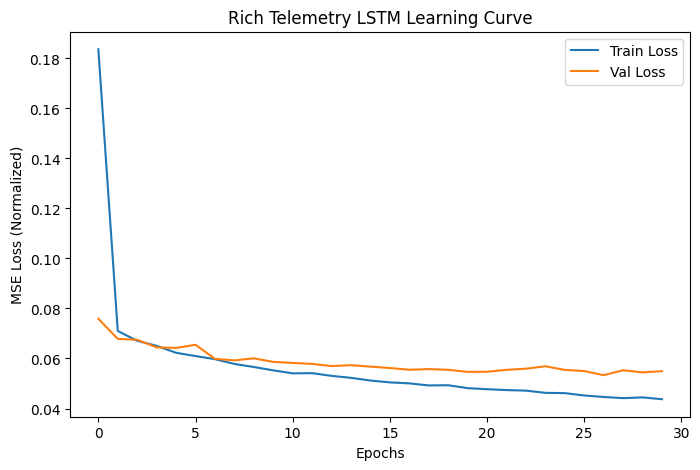

In [16]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 30
train_losses = []
val_losses = []

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, Y_batch)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * X_batch.size(0)
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, Y_batch in val_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, Y_batch)
            running_val_loss += loss.item() * X_batch.size(0)
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Rich Telemetry LSTM Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (Normalized)')
plt.legend()
plt.show()

### 5. Save the Weights

In [17]:
torch.save(model.state_dict(), 'rich_lstm_tracker.pth')
print("Model saved to rich_lstm_tracker.pth")

Model saved to rich_lstm_tracker.pth
